In [1]:
!module list 2>/dev/null || true
!nvidia-smi 2>/dev/null || true
!which mpirun 2>/dev/null || true
!which python3
%env HOROVOD_GPU_ALLREDUCE=NCCL
%env HOROVOD_GPU_ALLGATHER=NCCL
%env HOROVOD_GPU_BROADCAST=NCCL
%env NCCL_DEBUG=DEBUG

In [2]:
!nvidia-smi -L 2>/dev/null || echo 'No GPU or nvidia-smi available in current environment'

In [3]:
try:
    import horovod
    from horovod import run
    has_horovod = True
except (ImportError, ModuleNotFoundError):
    has_horovod = False
    run = None

def dummy(
    epochs=50,
    batch_size=8,
    base_channels=48,
    rrdb_blocks=4,
    growth_channels=24,
    levels=4,
    lambda_content=5.0,
    lambda_adversarial=0.05,
    lambda_gradient=1.0,
    lambda_spectral=0.2,
    lambda_feature_matching=1.0,
    critic_steps=1,
    shrink=16,
    sample_limit=None,
):
    #----------------------------------------
    # Import packages
    #----------------------------------------
    import sys
    import os
    os.environ["TF_DISABLE_NVTX_RANGES"] = "1"
    os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
    os.environ["NCCL_DEBUG"] = "WARN"
    import time
    import socket
    import math
    import numpy as np
    import xarray as xr
    try:
        import dask
        import dask.array as da
    except (ImportError, ModuleNotFoundError):
        pass
    try:
        import zarr as zr
    except (ImportError, ModuleNotFoundError):
        pass
    import pickle
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
    from tensorflow import keras
    from tensorflow.keras import layers, models, losses
    from tensorflow.keras.optimizers import Optimizer
    
    # Set logging level
    tf.get_logger().setLevel(tf.compat.v1.logging.ERROR)
    
    #------------------------------------------------------------
    # Initialise Horovod (with single-process fallback)
    #------------------------------------------------------------
    try:
        import horovod.tensorflow.keras as hvd
        hvd.init()
        has_hvd = True
    except Exception as e:
        has_hvd = False
        class DummyHVD:
            def size(self): return 1
            def rank(self): return 0
            def local_rank(self): return 0
            def allreduce(self, val, name=None): return val
        hvd = DummyHVD()
    
    # Pin GPU
    gpus = tf.config.experimental.list_physical_devices('GPU')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    if gpus and has_hvd:
        tf.config.experimental.set_visible_devices(gpus[hvd.local_rank()], 'GPU')
    
    #------------------------------------------------------------
    # Data Loading (xarray)
    #------------------------------------------------------------
    gadi_data_path = "/g/data/sd82/OFAM_AUSTRALIA/sst_10km_OFAM_historical_Australia.nc"
    local_data_path = "/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/sst_10km_OFAM_historical_Australia.nc"
    
    if os.path.exists(gadi_data_path):
        data_path = gadi_data_path
    elif os.path.exists(local_data_path):
        data_path = local_data_path
    else:
        raise FileNotFoundError(f"Could not find SST dataset at {gadi_data_path} or {local_data_path}")
    
    print(f"Loading dataset from {data_path} using xarray (decode_times=False)...")
    ds = xr.open_dataset(data_path, decode_times=False)
    sst = ds["temp"] if "temp" in ds else ds[list(ds.data_vars.keys())[0]]
    if "st_ocean" in sst.dims and sst.sizes["st_ocean"] == 1:
        sst = sst.squeeze("st_ocean")
    
    total_time = sst.shape[0]
    print(f"Total available time steps in dataset: {total_time}")
    
    if sample_limit is not None and sample_limit > 0:
        train_samples = min(sample_limit, total_time)
    else:
        train_samples = min(1000, total_time)
    
    print(f"Loading slice of {train_samples} time steps...")
    raw_data = np.asarray(sst[:train_samples, :, :].values, dtype=np.float32)
    print("Loaded raw data shape:", raw_data.shape)
    
    # Binary land mask (1 for ocean, 0 for land/NaN)
    nan_mask = np.isnan(raw_data)
    ocean_mask_single = (~np.isnan(raw_data[0])).astype(np.float32)
    raw_data = np.nan_to_num(raw_data, nan=0.0)
    
    # Normalisation parameters
    sst_min = np.min(raw_data[~nan_mask]) if np.any(~nan_mask) else 0.0
    sst_max = np.max(raw_data[~nan_mask]) if np.any(~nan_mask) else 35.0
    print(f"SST ocean range: min={sst_min:.2f} C, max={sst_max:.2f} C")
    norm_data = np.where(~nan_mask, (raw_data - sst_min) / (sst_max - sst_min + 1e-6), 0.0).astype(np.float32)
    
    H_fine, W_fine = norm_data.shape[1], norm_data.shape[2]
    H_coarse = H_fine // shrink
    W_coarse = W_fine // shrink
    print(f"Resolution: High-Res ({H_fine}x{W_fine}), Coarse ({H_coarse}x{W_coarse})")
    
    # Coarsen via block average over ocean
    N = len(norm_data)
    fine_targets = norm_data[:, :, :, np.newaxis] # (N, H, W, 1)
    fine_masks = np.repeat(ocean_mask_single[np.newaxis, :, :, np.newaxis], N, axis=0) # (N, H, W, 1)
    
    # Compute coarse condition: channel 0 = coarse SST, channel 1 = coarse ocean fraction
    reshaped = norm_data.reshape(N, H_coarse, shrink, W_coarse, shrink)
    mask_reshaped = fine_masks[:, :, :, 0].reshape(N, H_coarse, shrink, W_coarse, shrink)
    ocean_counts = mask_reshaped.sum(axis=(2, 4))
    ocean_fraction = ocean_counts / float(shrink * shrink)
    coarse_sst = np.where(ocean_counts > 0, (reshaped * mask_reshaped).sum(axis=(2, 4)) / np.maximum(ocean_counts, 1.0), 0.0)
    coarse_conditions = np.stack([coarse_sst, ocean_fraction], axis=-1).astype(np.float32) # (N, H_c, W_c, 2)
    
    # Train / Test split (80% train, 20% test)
    split_idx = int(0.8 * N)
    train_cond = coarse_conditions[:split_idx]
    train_mask = fine_masks[:split_idx]
    train_target = fine_targets[:split_idx]
    
    test_cond = coarse_conditions[split_idx:]
    test_mask = fine_masks[split_idx:]
    test_target = fine_targets[split_idx:]
    
    print(f"Train samples: {len(train_target)}, Test samples: {len(test_target)}")
    
    #------------------------------------------------------------
    # GAN Architecture Definition (TensorFlow Keras)
    #------------------------------------------------------------
    class ResidualDenseBlockTF(layers.Layer):
        def __init__(self, channels=48, growth_channels=24, **kwargs):
            super().__init__(**kwargs)
            self.convs = [layers.Conv2D(growth_channels, 3, padding="same") for _ in range(4)]
            self.fuse = layers.Conv2D(channels, 3, padding="same")
            self.act = layers.LeakyReLU(0.2)

        def call(self, x):
            features = [x]
            for conv in self.convs:
                cur = tf.concat(features, axis=-1)
                features.append(self.act(conv(cur)))
            fused = self.fuse(tf.concat(features, axis=-1))
            return x + 0.2 * fused

    class RRDBTF(layers.Layer):
        def __init__(self, channels=48, growth_channels=24, **kwargs):
            super().__init__(**kwargs)
            self.rdb1 = ResidualDenseBlockTF(channels, growth_channels)
            self.rdb2 = ResidualDenseBlockTF(channels, growth_channels)
            self.rdb3 = ResidualDenseBlockTF(channels, growth_channels)

        def call(self, x):
            return x + 0.2 * self.rdb3(self.rdb2(self.rdb1(x)))

    class UpsampleBlockTF(layers.Layer):
        def __init__(self, channels=48, condition_channels=2, **kwargs):
            super().__init__(**kwargs)
            self.conv = layers.Conv2D(channels, 3, padding="same")
            self.cond_conv = layers.Conv2D(channels, 1, padding="same")
            self.refine = layers.Conv2D(channels, 3, padding="same")
            self.act = layers.LeakyReLU(0.2)

        def call(self, values, condition, mask):
            H = tf.shape(values)[1]
            W = tf.shape(values)[2]
            up_size = (H * 2, W * 2)
            up_values = tf.image.resize(values, up_size, method="nearest")
            up_values = self.act(self.conv(up_values))
            cond_resized = tf.image.resize(condition, up_size, method="bilinear")
            mask_resized = tf.image.resize(mask, up_size, method="nearest")
            ctx = tf.concat([cond_resized, mask_resized], axis=-1)
            ref = self.act(self.refine(up_values + self.cond_conv(ctx)))
            return up_values + ref

    class GANGeneratorTF(keras.Model):
        def __init__(self, base_channels=48, levels=4, condition_channels=2,
                     target_channels=1, noise_channels=4, rrdb_blocks=4,
                     growth_channels=24, residual=True, **kwargs):
            super().__init__(**kwargs)
            self.levels = levels
            self.residual = residual
            self.noise_channels = noise_channels
            self.stem = layers.Conv2D(base_channels, 3, padding="same")
            self.trunk = [RRDBTF(base_channels, growth_channels) for _ in range(rrdb_blocks)]
            self.trunk_fuse = layers.Conv2D(base_channels, 3, padding="same")
            self.upsample = [UpsampleBlockTF(base_channels, condition_channels) for _ in range(levels)]
            self.head_conv1 = layers.Conv2D(base_channels, 3, padding="same")
            self.head_act = layers.LeakyReLU(0.2)
            self.head_conv2 = layers.Conv2D(target_channels, 3, padding="same",
                                            kernel_initializer="zeros", bias_initializer="zeros")

        def call(self, inputs, training=None):
            if isinstance(inputs, (list, tuple)):
                if len(inputs) == 3:
                    condition, mask, noise = inputs
                else:
                    condition, mask = inputs
                    noise = None
            else:
                condition = inputs
                mask = tf.ones_like(condition[:, :, :, :1])
                noise = None

            B = tf.shape(condition)[0]
            H_c = tf.shape(condition)[1]
            W_c = tf.shape(condition)[2]
            if noise is None:
                noise = tf.random.normal((B, H_c, W_c, self.noise_channels), dtype=condition.dtype)

            coarse_mask = tf.image.resize(mask, (H_c, W_c), method="nearest")
            stem_in = tf.concat([condition, noise, coarse_mask], axis=-1)
            h = self.stem(stem_in)
            h_trunk = h
            for block in self.trunk:
                h_trunk = block(h_trunk)
            h = h + self.trunk_fuse(h_trunk)

            for up_block in self.upsample:
                h = up_block(h, condition, mask)

            out = self.head_act(self.head_conv1(h))
            out = self.head_conv2(out)

            if self.residual:
                H_f = tf.shape(mask)[1]
                W_f = tf.shape(mask)[2]
                out = out + tf.image.resize(condition[:, :, :, :1], (H_f, W_f), method="bilinear")

            return out * mask

    class PatchCriticTF(layers.Layer):
        def __init__(self, base_channels=32, levels=4, **kwargs):
            super().__init__(**kwargs)
            channels = [base_channels * min(2**i, 8) for i in range(levels)]
            self.convs = [layers.Conv2D(ch, 4, strides=2, padding="same") for ch in channels]
            self.out_conv = layers.Conv2D(1, 3, padding="same")
            self.act = layers.LeakyReLU(0.2)

        def call(self, x):
            h = x
            features = []
            for conv in self.convs:
                h = self.act(conv(h))
                features.append(h)
            logits = self.out_conv(h)
            return logits, features

    class DiscriminatorTF(keras.Model):
        def __init__(self, base_channels=32, levels=4, scales=2, **kwargs):
            super().__init__(**kwargs)
            self.critics = [PatchCriticTF(base_channels, levels) for _ in range(scales)]

        def call(self, inputs, training=None):
            field, condition, ocean_mask = inputs
            H = tf.shape(field)[1]
            W = tf.shape(field)[2]
            cond_up = tf.image.resize(condition, (H, W), method="bilinear")
            x = tf.concat([field * ocean_mask, cond_up, ocean_mask], axis=-1)
            all_logits = []
            all_features = []
            for i, critic in enumerate(self.critics):
                if i > 0:
                    x = tf.nn.avg_pool2d(x, 2, 2, padding="SAME")
                logits, feats = critic(x)
                all_logits.append(logits)
                all_features.extend(feats)
            return all_logits, all_features

    def masked_mse(pred, target, mask):
        diff_sq = tf.square(pred - target) * mask
        denom = tf.maximum(tf.reduce_sum(mask), 1.0)
        return tf.reduce_sum(diff_sq) / denom

    def masked_gradient_loss(pred, target, mask):
        dx_p = pred[:, :, 1:, :] - pred[:, :, :-1, :]
        dx_t = target[:, :, 1:, :] - target[:, :, :-1, :]
        dx_m = mask[:, :, 1:, :] * mask[:, :, :-1, :]
        dy_p = pred[:, 1:, :, :] - pred[:, :-1, :, :]
        dy_t = target[:, 1:, :, :] - target[:, :-1, :, :]
        dy_m = mask[:, 1:, :, :] * mask[:, :-1, :, :]
        lx = tf.reduce_sum(tf.abs(dx_p - dx_t) * dx_m) / tf.maximum(tf.reduce_sum(dx_m), 1.0)
        ly = tf.reduce_sum(tf.abs(dy_p - dy_t) * dy_m) / tf.maximum(tf.reduce_sum(dy_m), 1.0)
        return lx + ly

    class GANTrainer(keras.Model):
        def __init__(self, generator, discriminator,
                     lambda_content=5.0,
                     lambda_adversarial=0.05,
                     lambda_gradient=1.0,
                     lambda_spectral=0.2,
                     lambda_feature_matching=1.0,
                     critic_steps=1,
                     **kwargs):
            super().__init__(**kwargs)
            self.generator = generator
            self.discriminator = discriminator
            self.lambda_content = lambda_content
            self.lambda_adversarial = lambda_adversarial
            self.lambda_gradient = lambda_gradient
            self.lambda_spectral = lambda_spectral
            self.lambda_feature_matching = lambda_feature_matching
            self.critic_steps = critic_steps
            self.g_loss_tracker = keras.metrics.Mean(name="g_loss")
            self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
            self.content_tracker = keras.metrics.Mean(name="content")
            self.adv_tracker = keras.metrics.Mean(name="adv")

        def compile(self, g_optimizer, d_optimizer):
            super().compile()
            self.g_optimizer = g_optimizer
            self.d_optimizer = d_optimizer

        @property
        def metrics(self):
            return [self.g_loss_tracker, self.d_loss_tracker, self.content_tracker, self.adv_tracker]

        def train_step(self, data):
            if len(data) == 2:
                (condition, mask), target = data
            else:
                condition, mask = data[0]
                target = data[1]

            # Critic update
            for _ in range(self.critic_steps):
                with tf.GradientTape() as d_tape:
                    fake = self.generator((condition, mask), training=False)
                    real_logits_list, _ = self.discriminator((target, condition, mask), training=True)
                    fake_logits_list, _ = self.discriminator((fake, condition, mask), training=True)
                    d_loss = 0.0
                    for r_logits, f_logits in zip(real_logits_list, fake_logits_list):
                        d_loss += tf.reduce_mean(tf.nn.relu(1.0 - r_logits)) + tf.reduce_mean(tf.nn.relu(1.0 + f_logits))
                d_grads = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
                d_grads, _ = tf.clip_by_global_norm(d_grads, 1.0)
                self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_variables))

            # Generator update
            with tf.GradientTape() as g_tape:
                fake = self.generator((condition, mask), training=True)
                content_loss = masked_mse(fake, target, mask)
                fake_logits_list, fake_feats = self.discriminator((fake, condition, mask), training=False)
                _, real_feats = self.discriminator((target, condition, mask), training=False)
                adv_loss = 0.0
                for f_logits in fake_logits_list:
                    adv_loss += -tf.reduce_mean(f_logits)
                grad_loss = masked_gradient_loss(fake, target, mask)
                feat_loss = 0.0
                for ff, rf in zip(fake_feats, real_feats):
                    feat_loss += tf.reduce_mean(tf.abs(ff - rf))
                g_loss = (self.lambda_content * content_loss
                          + self.lambda_adversarial * adv_loss
                          + self.lambda_gradient * grad_loss
                          + self.lambda_feature_matching * feat_loss)
            g_grads = g_tape.gradient(g_loss, self.generator.trainable_variables)
            g_grads, _ = tf.clip_by_global_norm(g_grads, 1.0)
            self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_variables))

            self.g_loss_tracker.update_state(g_loss)
            self.d_loss_tracker.update_state(d_loss)
            self.content_tracker.update_state(content_loss)
            self.adv_tracker.update_state(adv_loss)
            return {
                "g_loss": self.g_loss_tracker.result(),
                "d_loss": self.d_loss_tracker.result(),
                "content": self.content_tracker.result(),
                "adv": self.adv_tracker.result(),
            }

        def test_step(self, data):
            if len(data) == 2:
                (condition, mask), target = data
            else:
                condition, mask = data[0]
                target = data[1]
            fake = self.generator((condition, mask), training=False)
            content_loss = masked_mse(fake, target, mask)
            self.content_tracker.update_state(content_loss)
            return {"content": self.content_tracker.result()}

    # Instantiate models
    generator = GANGeneratorTF(
        base_channels=base_channels,
        levels=levels,
        condition_channels=2,
        target_channels=1,
        noise_channels=4,
        rrdb_blocks=rrdb_blocks,
        growth_channels=growth_channels,
        residual=True,
    )
    discriminator = DiscriminatorTF(
        base_channels=32,
        levels=levels,
        scales=2,
    )
    
    # Call once to build shapes
    _ = generator((train_cond[:1], train_mask[:1]))
    _ = discriminator((train_target[:1], train_cond[:1], train_mask[:1]))
    
    print(f"GAN Generator total trainable parameters: {generator.count_params():,}")
    print(f"GAN Discriminator total trainable parameters: {discriminator.count_params():,}")
    
    trainer = GANTrainer(
        generator,
        discriminator,
        lambda_content=lambda_content,
        lambda_adversarial=lambda_adversarial,
        lambda_gradient=lambda_gradient,
        lambda_spectral=lambda_spectral,
        lambda_feature_matching=lambda_feature_matching,
        critic_steps=critic_steps,
    )
    
    lr_scale = hvd.size() if has_hvd else 1.0
    g_opt = keras.optimizers.Adam(learning_rate=0.0001 * lr_scale, beta_1=0.0, beta_2=0.99)
    d_opt = keras.optimizers.Adam(learning_rate=0.0002 * lr_scale, beta_1=0.0, beta_2=0.99)
    trainer.compile(g_optimizer=g_opt, d_optimizer=d_opt)
    
    callbacks = []
    if hvd.rank() == 0:
        callbacks.append(keras.callbacks.EarlyStopping(monitor='val_content', patience=10, restore_best_weights=False, verbose=1))
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_content', factor=0.5, patience=5, verbose=1))
    
    print("Starting GAN standard model.fit training...")
    start_time = time.time()
    history = trainer.fit(
        x=(train_cond, train_mask),
        y=train_target,
        validation_data=((test_cond, test_mask), test_target),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=2 if hvd.rank() == 0 else 0,
    )
    elapsed = time.time() - start_time
    print(f"Training finished in {elapsed:.1f} seconds.")
    
    return {
        "generator": generator,
        "discriminator": discriminator,
        "trainer": trainer,
        "history": history.history if hasattr(history, 'history') else {},
        "train_data": (train_cond, train_mask, train_target),
        "test_data": (test_cond, test_mask, test_target),
        "norm": (sst_min, sst_max),
    }

In [4]:
# Train GAN model with standard arguments
results = dummy(
    epochs=5,
    batch_size=4,
    base_channels=48,
    rrdb_blocks=4,
    growth_channels=24,
    levels=4,
    lambda_content=5.0,
    lambda_adversarial=0.05,
    lambda_gradient=1.0,
    lambda_spectral=0.2,
    lambda_feature_matching=1.0,
    sample_limit=16,
)

TensorFlow version: 2.15.1
Loading dataset from /esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/sst_10km_OFAM_historical_Australia.nc using xarray (decode_times=False)...
Total available time steps in dataset: 13149
Loading slice of 16 time steps...
Loaded raw data shape: (16, 512, 512)
SST ocean range: min=4.87 C, max=36.46 C
Resolution: High-Res (512x512), Coarse (32x32)
Train samples: 12, Test samples: 4
GAN Generator total trainable parameters: 1,831,249
GAN Discriminator total trainable parameters: 1,385,922
Starting GAN standard model.fit training...
Epoch 1/5
3/3 - 18s - g_loss: 0.0117 - d_loss: 4.0024 - content: 5.0902e-04 - adv: -3.2107e-02 - val_content: 3.0143e-04 - lr: 0.0010 - 18s/epoch - 6s/step
Epoch 2/5
3/3 - 10s - g_loss: 0.0092 - d_loss: 3.9999 - content: 3.0688e-04 - adv: -2.5152e-02 - val_content: 2.6330e-04 - lr: 0.0010 - 10s/epoch - 3s/step
Epoch 3/5
3/3 - 10s - g_loss: 0.0094 - d_loss: 3.9997 - content: 2.5676e-04 - adv: -7.7773e-03 - val_content:

In [5]:
# Multi-GPU Horovod execution (if available)
if has_horovod and run is not None:
    print("Running distributed training with Horovod...")
    # run(dummy, np=4, args=(50, 8, 48, 4, 24, 4, 5.0, 0.05, 1.0, 0.2, 1.0, 1, 16, None))
else:
    print("Single-process mode active. Horovod multi-GPU execution available when invoked under mpirun/hvd.")

Single-process mode active. Horovod multi-GPU execution available when invoked under mpirun/hvd.


Evaluated sample 0: Ocean MAE = 0.2702 C, Ocean RMSE = 0.4740 C


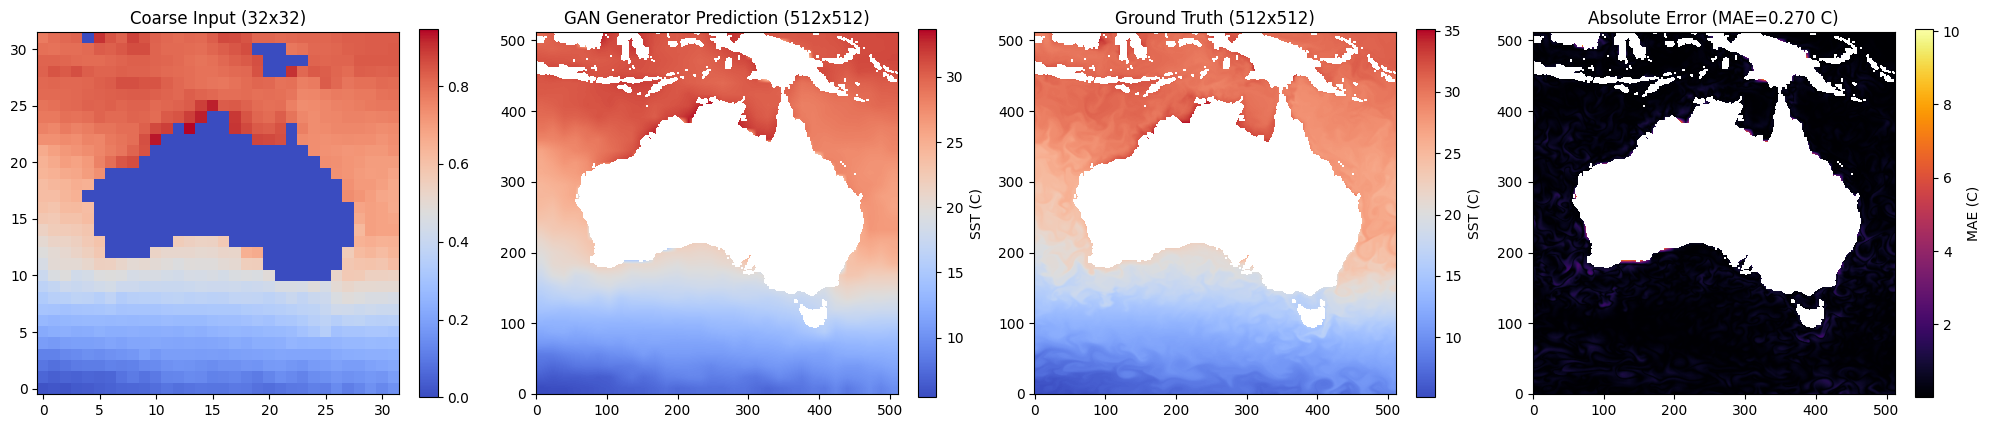

In [6]:
import matplotlib.pyplot as plt
import numpy as np

if 'results' in locals() and 'generator' in results:
    gen = results['generator']
    test_cond, test_mask, test_target = results['test_data']
    sst_min, sst_max = results['norm']
    
    sample_idx = 0
    pred_norm = gen((test_cond[sample_idx:sample_idx+1], test_mask[sample_idx:sample_idx+1]), training=False).numpy()[0, :, :, 0]
    targ_norm = test_target[sample_idx, :, :, 0]
    cond_norm = test_cond[sample_idx, :, :, 0]
    mask = test_mask[sample_idx, :, :, 0]
    
    # Denormalise
    pred_phys = np.where(mask > 0.5, pred_norm * (sst_max - sst_min) + sst_min, np.nan)
    targ_phys = np.where(mask > 0.5, targ_norm * (sst_max - sst_min) + sst_min, np.nan)
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    im0 = axes[0].imshow(cond_norm, cmap='coolwarm', origin='lower')
    axes[0].set_title("Coarse Input (32x32)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    im1 = axes[1].imshow(pred_phys, cmap='coolwarm', origin='lower')
    axes[1].set_title(f"GAN Generator Prediction ({pred_phys.shape[0]}x{pred_phys.shape[1]})")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, label='SST (C)')
    
    im2 = axes[2].imshow(targ_phys, cmap='coolwarm', origin='lower')
    axes[2].set_title(f"Ground Truth ({targ_phys.shape[0]}x{targ_phys.shape[1]})")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, label='SST (C)')
    
    err = np.where(mask > 0.5, np.abs(pred_phys - targ_phys), np.nan)
    im3 = axes[3].imshow(err, cmap='inferno', origin='lower')
    axes[3].set_title(f"Absolute Error (MAE={np.nanmean(err):.3f} C)")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, label='MAE (C)')
    
    plt.tight_layout()
    plt.savefig("/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/SRDN/sst_gan_stand_eval.png", dpi=150)
    plt.show()
    print(f"Evaluated sample {sample_idx}: Ocean MAE = {np.nanmean(err):.4f} C, Ocean RMSE = {np.sqrt(np.nanmean(err**2)):.4f} C")
else:
    print("Results not available for visualization.")